# 📺 Netflix Recommendation System Project

## **Overview**
Build a **Netflix-style movie recommender** using real user ratings to predict **movies a user might like**.

### **Steps**
1. **Data Cleaning & Understanding**  
   - Netflix Prize dataset: messy, millions of ratings.  
   - Fix movie IDs, text ratings, missing/duplicate values.

2. **EDA**  
   - Check rating distribution, top movies, active users.  
   - Visualize user-movie matrix sparsity.

3. **Recommendation System**  
   - Model-based **Collaborative Filtering** using **SVD**.  
   - Handle sparse matrices and predict unseen ratings with **Surprise library**.

4. **Evaluation**  
   - Use **RMSE** to measure prediction accuracy.  

5. **Generating Recommendations**  
   - Suggest top movies a user hasn’t watched.  
   - Compare recommendations across users if needed.

---

## **Key Concepts**
- **User-Item Matrix:** Users × Movies table with ratings.  
- **Collaborative Filtering:** Recommend based on **similar users**.  
- **SVD:** Reduces sparse matrix into **latent factors** for users/movies.  
- **Surprise Library:** Simplifies **building and evaluating models**.

---

## **Why It’s Useful**
- Used in Netflix, Amazon, Spotify, YouTube.  
- Learn **data cleaning, matrix factorization, and evaluation** on real data.  
- Understand **how big tech predicts user preferences**.


**********

### **Importing basic libraries**

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

---------------

## **Data Cleaning & Transformation**

### **Fixing the parsing problem of dataset** 
The dataset lists movie IDs as a header row, followed by ratings for that movie:

| Cust\_Id | Rating |
| -------- | ------ |
| 1:       |        |
| 1488844  | 3      |
| 822109   | 5      |

#### **After fixing:**

|Movie_Id| Cust\_Id | Rating |
|---------| -------- | ------ |
| 1       | 1488844  | 3      |
| 1       | 822109   | 5      |

- Movie_Id column explicitly matches each rating.
- Cust_Id column only contains actual customer IDs.
- All columns have proper datatype


- *The movie rating files contain over 100 million ratings from 480 thousand randomly-chosen, anonymous Netflix customers over 17 thousand movie titles. The combined_data_1.txt.zip is one of the fragments of the entire 100M ratings dataset. We'll only work on one fragment to avoid long training time and reduce overhead during cleaning. This one fragment has 4499 movies and ratings from about 470758 users. One user can have rated more than one movie. The entire dataset is contained in txt files and this one of the txt files.*

- *The movie_titles.csv file contains titles of all the movies wihtout duplicates*

----------

In [2]:
df = pd.read_csv('C:\\Users\\ksaid\\Documents\\porjects\\Netflix Project\\combined_data_1.txt\\combined_data_1.txt', header=None, names = ['Cust_Id', 'Rating'], usecols = [0,1]) 
df

,Cust_Id,Rating
0,1:,NaN
1,1488844,3.0
2,822109,5.0
3,885013,4.0
4,30878,4.0
...,...,...
24058258,2591364,2.0
24058259,1791000,2.0
24058260,512536,5.0
24058261,988963,3.0


In [3]:
df['Movie_Id'] =df['Cust_Id'].where(df['Cust_Id'].str.endswith(':'), pd.NA) #fetches the values with indices which fulfil the condtion & puts NA if it does not 

In [4]:
df['Movie_Id']= df['Movie_Id'].ffill() # forward fills the empty values movie id  
df 

,Cust_Id,Rating,Movie_Id
0,1:,NaN,1:
1,1488844,3.0,1:
2,822109,5.0,1:
3,885013,4.0,1:
4,30878,4.0,1:
...,...,...,...
24058258,2591364,2.0,4499:
24058259,1791000,2.0,4499:
24058260,512536,5.0,4499:
24058261,988963,3.0,4499:


In [5]:
df.dropna(inplace=True) # drops all rows with null values  

In [6]:
df['Movie_Id']= df['Movie_Id'].str.replace(':','') #1: -> 1

In [7]:
df = df.astype('int') #converting to int

In [8]:
df

,Cust_Id,Rating,Movie_Id
1,1488844,3,1
2,822109,5,1
3,885013,4,1
4,30878,4,1
5,823519,3,1
...,...,...,...
24058258,2591364,2,4499
24058259,1791000,2,4499
24058260,512536,5,4499
24058261,988963,3,4499


- **now all the columns are ready for analysis**

-------------

### **Sanity Check**

In [9]:
df.isnull().sum()


Cust_Id     0
Rating      0
Movie_Id    0
dtype: int64

In [10]:
df.duplicated().sum()

0

In [11]:
rating_count =df['Rating'].value_counts()

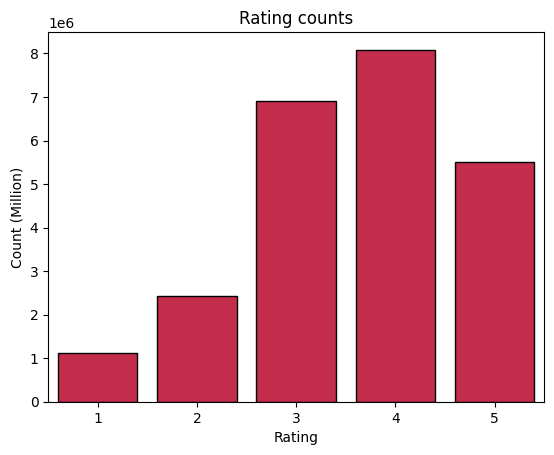

In [12]:
sns.barplot(x=rating_count.index, y=rating_count.values, color='crimson', edgecolor='black') #smol visualization to see the ratings count
plt.title('Rating counts')
plt.ylabel('Count (Million)')
plt.show()

In [13]:
df['Cust_Id'].nunique() #total customers who rated without duplicates

470758

In [14]:
df['Movie_Id'].nunique() #total movies

4499

---------

## **Training SVD model**

- *If you dont have Anaconda configured, then install it to use the conda command below. I dont know how to fix the requirement for the installation when I did with pip. So this is only way to do it wihtout hassle.*

In [15]:
#conda install -c conda-forge scikit-surprise --yes

In [16]:
import sys
sys.path.insert(0, r'C:\Users\ksaid\Documents\porjects\Netflix Project')
import importlib
import surprise
importlib.reload(surprise)
from surprise import SVD, Dataset, Reader
from surprise.model_selection import train_test_split
from surprise import accuracy


### **Smol Note on SVD**

- SVD (Singular Value Decomposition) breaks a large matrix into smaller factors.
- In recommender systems:
    - User–Movie rating matrix → decomposed into latent features (hidden patterns).
    - Helps predict missing ratings by capturing user taste + movie characteristics.

In [17]:
reader = Reader(rating_scale=(1,5)) #because our rating ranges from 1 to 5
data = Dataset.load_from_df(df[['Cust_Id', 'Movie_Id', 'Rating']], reader)

In [18]:
train, test = train_test_split(data, test_size=0.2) #80% training= 19M rows; 20% testing = 5M rows

In [19]:
model = SVD()
model.fit(train) #will take forveer to train so this is why we didnt took the whole 100M dataset

---------------

## **Evaluation**

In [20]:
pred = model.test(test) #predict the unseen test data

### **Acceptable RMSE Range**

- RMSE (Root Mean Squared Error) measures how far predicted ratings are from actual ratings.
- Netflix Prize baseline was ~0.85.
- We got 0.90 on one of the fragment of the entire dataset.

In [21]:
accuracy.rmse(pred) 

0.9457781493364268

*structure of the prediction tuple:*

**Prediction(uid=2158514, iid=199, r_ui=3.0, est=3.4088694474825956, details={'was_impossible': False})**

In [22]:
act_pred = [i[2:4] for i in pred]
pred_table = pd.DataFrame(act_pred, columns=['Actual', 'Predicted']).head(10)
pred_table['diff'] = abs(pred_table['Actual'] - pred_table['Predicted'])
print("MAE: ", pred_table['diff'].mean())
pred_table

MAE:  0.8962845515795216


,Actual,Predicted,diff
0,3,2.648341,0.351659
1,3,2.316365,0.683635
2,3,3.094908,0.094908
3,5,3.627667,1.372333
4,2,3.397566,1.397566
5,5,3.019343,1.980657
6,3,3.883246,0.883246
7,5,4.107036,0.892964
8,4,3.369168,0.630832
9,4,3.324955,0.675045


----------

## **Applying the Recommendation Engine**

*When reading the file with classic pd.read_csv() I found that some movie titles have commas so that interfered with the pandas' file reading which saw commas as delimiters. So we needed to split() eeach row only with only first two commas and ignore the rest. We stored the whole dataset in a list of lists where each list contained a row. Then later convert that into a DataFrame.*

In [23]:
titles=[]
with open("C:\\Users\\ksaid\\Documents\\porjects\\Netflix Project\\movie_titles.csv",encoding="cp1252") as f:
    for line in f:
        title = line.strip().split(',',2)
        titles.append(title)

In [24]:
df_titles = pd.DataFrame(titles, columns=['Movie_Id', 'Year', 'Title'])
df_titles['Movie_Id'] =df_titles['Movie_Id'].astype('int')
df_titles

,Movie_Id,Year,Title
0,1,2003,Dinosaur Planet
1,2,2004,Isle of Man TT 2004 Review
2,3,1997,Character
3,4,1994,Paula Abdul's Get Up & Dance
4,5,2004,The Rise and Fall of ECW
...,...,...,...
17765,17766,2002,Where the Wild Things Are and Other Maurice Se...
17766,17767,2004,Fidel Castro: American Experience
17767,17768,2000,Epoch
17768,17769,2003,The Company


In [25]:
user = 1432211 #random user
user_movies = df[df['Cust_Id']==user]['Movie_Id'].unique() #all movies rated by the selected user

In [26]:
unrated = df_titles[~df_titles['Movie_Id'].isin(user_movies)] #all movies NOT rated by the selected user
unrated

,Movie_Id,Year,Title
0,1,2003,Dinosaur Planet
1,2,2004,Isle of Man TT 2004 Review
3,4,1994,Paula Abdul's Get Up & Dance
4,5,2004,The Rise and Fall of ECW
5,6,1997,Sick
...,...,...,...
17765,17766,2002,Where the Wild Things Are and Other Maurice Se...
17766,17767,2004,Fidel Castro: American Experience
17767,17768,2000,Epoch
17768,17769,2003,The Company


In [27]:
pred_unrated =[]
for i in unrated['Movie_Id']: #movie ids of the unrated movies
    prediction = model.predict(user,i) #predict() requires the user id and the movie id
    pred_unrated.append((i, prediction.est)) #movie id and estimated rating 


In [28]:
recommendations = pd.DataFrame(pred_unrated, columns=['Movie_Id', 'Rating'])
recommendations = recommendations.merge(df_titles, on='Movie_Id') #movie id is the primary key in both dataframes

In [29]:
recommendations

,Movie_Id,Rating,Year,Title
0,1,3.688077,2003,Dinosaur Planet
1,2,3.380668,2004,Isle of Man TT 2004 Review
2,4,2.651605,1994,Paula Abdul's Get Up & Dance
3,5,3.838917,2004,The Rise and Fall of ECW
4,6,3.013893,1997,Sick
...,...,...,...,...
17567,17766,3.515528,2002,Where the Wild Things Are and Other Maurice Se...
17568,17767,3.515528,2004,Fidel Castro: American Experience
17569,17768,3.515528,2000,Epoch
17570,17769,3.515528,2003,The Company


In [30]:
top_10 = recommendations.nlargest(10, columns='Rating') #top 10 movies with highest predicted rating
top_10

,Movie_Id,Rating,Year,Title
3305,3456,4.588717,2004,Lost: Season 1
2901,3033,4.535074,2005,Ghost in the Shell: Stand Alone Complex: 2nd Gig
1998,2102,4.496173,1994,The Simpsons: Season 6
4057,4238,4.465429,2000,Inu-Yasha
3293,3444,4.430700,2004,Family Guy: Freakin' Sweet Collection
11,13,4.405756,2003,Lord of the Rings: The Return of the King: Ext...
4233,4427,4.384643,2001,The West Wing: Season 3
1401,1476,4.384457,2004,Six Feet Under: Season 4
1918,2019,4.382878,2004,Samurai Champloo
2446,2568,4.376764,2004,Stargate SG-1: Season 8


### **Observations from Predicted Ratings**
- The predicted ratings range approximately between **4.3 and 4.63**, indicating that the model expects the user to **like all of these movies**.
- The **highest predicted rating** is for *House of Cards Trilogy I: House of Cards* (4.63), which suggests a strong alignment with the user's past preferences.
- Even though the model **does not explicitly know movie genres**, it is able to capture latent user interests through **patterns in the user-movie rating matrix**. This is the core power of SVD in collaborative filtering: by decomposing the sparse ratings matrix into latent factors, it identifies hidden relationships between movies and users. Movies that have similar rating patterns among users get grouped together in this latent space, allowing the model to make meaningful predictions.


- According to online sources, **most of the recommended movies fall into the “Drama” or “Political thriller / Thriller” genres**. This includes the *House of Cards* trilogy, *Upstairs, Downstairs*, and *Lost: Season 1*.  
- Additionally, the model recommends movies that are **classics or family-oriented** such as *The Wizard of Oz* (Musical, Fantasy, Adventure) and *I Love Lucy: Season 5* (Sitcom, Comedy), showing that **latent factors capture preferences beyond just genres**, likely reflecting user ratings for highly rated classics.  
- Some recommendations like *The Life of Birds* (Nature documentary) and *Solaris* (Science fiction) indicate **diversity in the latent factors**, meaning that users with similar rating patterns to this user have also enjoyed these types of movies. These might not belong to the dominant genres of the top picks but appear because the **collabora

* In conclusion, the SVD model successfully identifies hidden relationships in the data and recommends a balanced mix of popular, classic, and genre-specific movies. This table serves as a clear illustration of **latent factor modeling** in collaborative filtering and demonstrates its effectiveness even in a large, sparse dataset like Netflix.

---------------